# 07 — Environmental Impact Analysis

> **Objective:** Analyze the relationship between weather conditions and air quality metrics. Use feature importance analysis (Random Forest, LightGBM, SHAP) to understand which weather factors most influence air quality.

---

## 1. Setup and Load Data

Import libraries and load raw weather data with air quality columns.

In [1]:
from pathlib import Path
import sys
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import shap

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_loader import load_raw_weather, add_region_column

reports_dir = project_root / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

df = load_raw_weather(project_root)
df = add_region_column(df)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (133000, 23)
Columns: ['last_updated', 'temperature_celsius', 'humidity', 'wind_kph', 'wind_degree', 'pressure_mb', 'precip_mm', 'cloud', 'feelslike_celsius', 'visibility_km', 'uv_index', 'gust_kph', 'continent', 'country', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'region']


## 2. Identify Air Quality Columns

Find all air quality related columns in the dataset.

In [2]:
air_quality_cols = [c for c in df.columns if "air_quality" in c.lower()]
print("Air quality columns found:")
for col in air_quality_cols:
    non_null = df[col].notna().sum()
    print(f"  {col}: {non_null:,} non-null ({non_null/len(df)*100:.1f}%)")

Air quality columns found:
  air_quality_Carbon_Monoxide: 133,000 non-null (100.0%)
  air_quality_Ozone: 133,000 non-null (100.0%)
  air_quality_Nitrogen_dioxide: 133,000 non-null (100.0%)
  air_quality_Sulphur_dioxide: 133,000 non-null (100.0%)
  air_quality_PM2.5: 133,000 non-null (100.0%)
  air_quality_PM10: 133,000 non-null (100.0%)
  air_quality_us-epa-index: 133,000 non-null (100.0%)
  air_quality_gb-defra-index: 133,000 non-null (100.0%)


In [3]:
# Define weather columns for correlation analysis
weather_cols = [
    "temperature_celsius",
    "humidity",
    "wind_kph",
    "wind_degree",
    "pressure_mb",
    "precip_mm",
    "cloud",
    "feelslike_celsius",
    "visibility_km",
    "uv_index",
    "gust_kph",
]

# Filter to existing columns
weather_cols = [c for c in weather_cols if c in df.columns]
print("Weather columns for analysis:", weather_cols)

Weather columns for analysis: ['temperature_celsius', 'humidity', 'wind_kph', 'wind_degree', 'pressure_mb', 'precip_mm', 'cloud', 'feelslike_celsius', 'visibility_km', 'uv_index', 'gust_kph']


## 3. Air Quality Distribution

Visualize the distribution of air quality metrics.

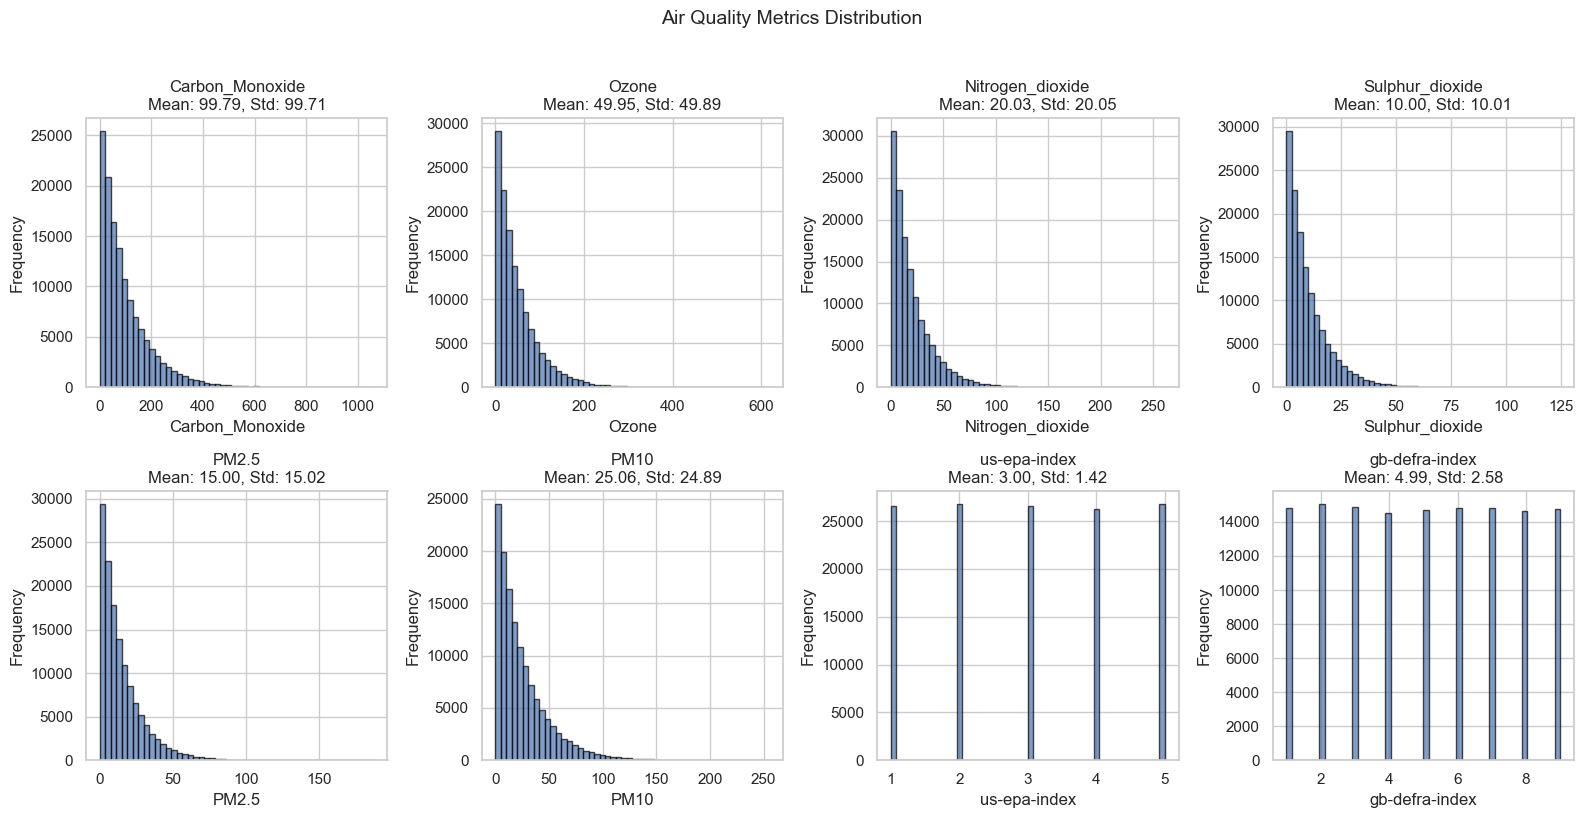

Saved: C:\Users\lucas\OneDrive\Desktop\pma-weather-forecasting\reports\env_air_quality_distributions.png


In [4]:
numeric_aq_cols = [c for c in air_quality_cols if df[c].dtype in ["float64", "int64"]]

n_cols = min(4, len(numeric_aq_cols))
n_rows = (len(numeric_aq_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for i, col in enumerate(numeric_aq_cols):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=50, edgecolor="black", alpha=0.7)
    ax.set_xlabel(col.replace("air_quality_", ""))
    ax.set_ylabel("Frequency")
    ax.set_title(f"{col.replace('air_quality_', '')}\nMean: {data.mean():.2f}, Std: {data.std():.2f}")

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Air Quality Metrics Distribution", y=1.02, fontsize=14)
plt.tight_layout()
out_path = reports_dir / "env_air_quality_distributions.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

## 4. Weather vs Air Quality Correlation

Compute and visualize correlation between weather and air quality variables.

Rows with complete data: 133,000 (100.0%)


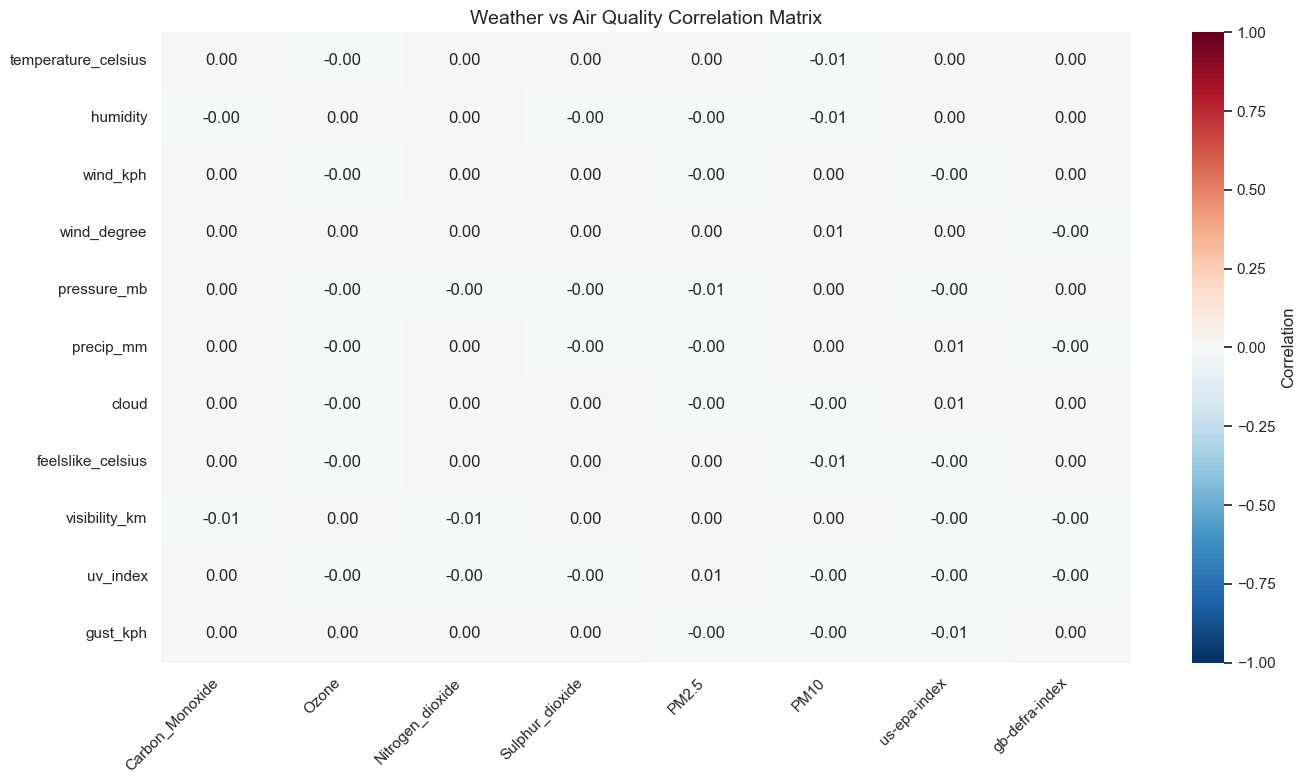

Saved: C:\Users\lucas\OneDrive\Desktop\pma-weather-forecasting\reports\env_weather_airquality_correlation.png


In [5]:
all_cols = weather_cols + numeric_aq_cols
corr_df = df[all_cols].dropna()

print(f"Rows with complete data: {len(corr_df):,} ({len(corr_df)/len(df)*100:.1f}%)")

corr_matrix = corr_df.corr()

# Extract weather vs air quality correlations
weather_aq_corr = corr_matrix.loc[weather_cols, numeric_aq_cols]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    weather_aq_corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    cbar_kws={"label": "Correlation"},
)
ax.set_title("Weather vs Air Quality Correlation Matrix", fontsize=14)
ax.set_xticklabels([c.replace("air_quality_", "") for c in numeric_aq_cols], rotation=45, ha="right")

plt.tight_layout()
out_path = reports_dir / "env_weather_airquality_correlation.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

## 5. Top Correlations

Identify and visualize the strongest weather-air quality correlations.

In [6]:
# Flatten correlation matrix to find top pairs
corr_pairs = []
for weather_col in weather_cols:
    for aq_col in numeric_aq_cols:
        corr_val = weather_aq_corr.loc[weather_col, aq_col]
        corr_pairs.append({
            "Weather": weather_col,
            "Air Quality": aq_col.replace("air_quality_", ""),
            "Correlation": corr_val,
            "Abs Correlation": abs(corr_val),
        })

corr_pairs_df = pd.DataFrame(corr_pairs).sort_values("Abs Correlation", ascending=False)
print("Top 10 Correlations (by absolute value):")
display(corr_pairs_df.head(10))

Top 10 Correlations (by absolute value):


,Weather,Air Quality,Correlation,Abs Correlation
54,cloud,us-epa-index,0.007727,0.007727
5,temperature_celsius,PM10,-0.006298,0.006298
64,visibility_km,Carbon_Monoxide,-0.006223,0.006223
46,precip_mm,us-epa-index,0.006044,0.006044
61,feelslike_celsius,PM10,-0.005969,0.005969
29,wind_degree,PM10,0.005815,0.005815
36,pressure_mb,PM2.5,-0.005626,0.005626
13,humidity,PM10,-0.005625,0.005625
66,visibility_km,Nitrogen_dioxide,-0.005425,0.005425
76,uv_index,PM2.5,0.005026,0.005026


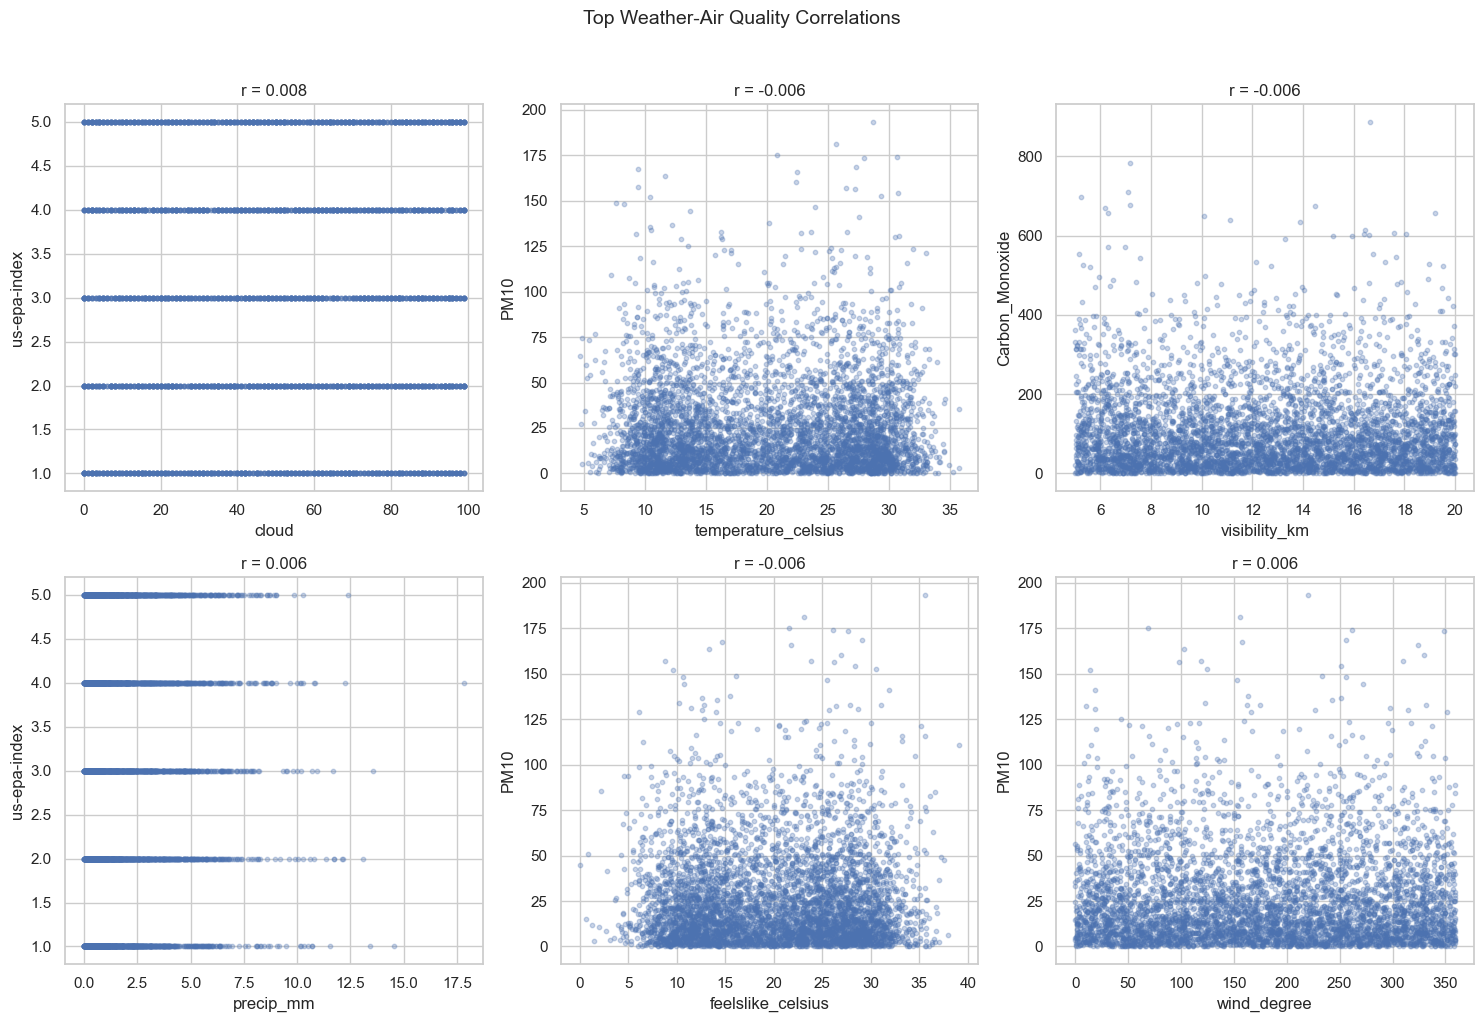

Saved: C:\Users\lucas\OneDrive\Desktop\pma-weather-forecasting\reports\env_top_correlations_scatter.png


In [7]:
# Scatter plots for top 6 correlations
top_6 = corr_pairs_df.head(6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

sample = corr_df.sample(min(5000, len(corr_df)), random_state=42)

for i, (_, row) in enumerate(top_6.iterrows()):
    ax = axes[i]
    weather_col = row["Weather"]
    aq_col = "air_quality_" + row["Air Quality"]
    
    ax.scatter(sample[weather_col], sample[aq_col], alpha=0.3, s=10)
    ax.set_xlabel(weather_col)
    ax.set_ylabel(row["Air Quality"])
    ax.set_title(f"r = {row['Correlation']:.3f}")

plt.suptitle("Top Weather-Air Quality Correlations", y=1.02, fontsize=14)
plt.tight_layout()
out_path = reports_dir / "env_top_correlations_scatter.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

## 6. Air Quality by Region

Compare air quality metrics across geographic regions.

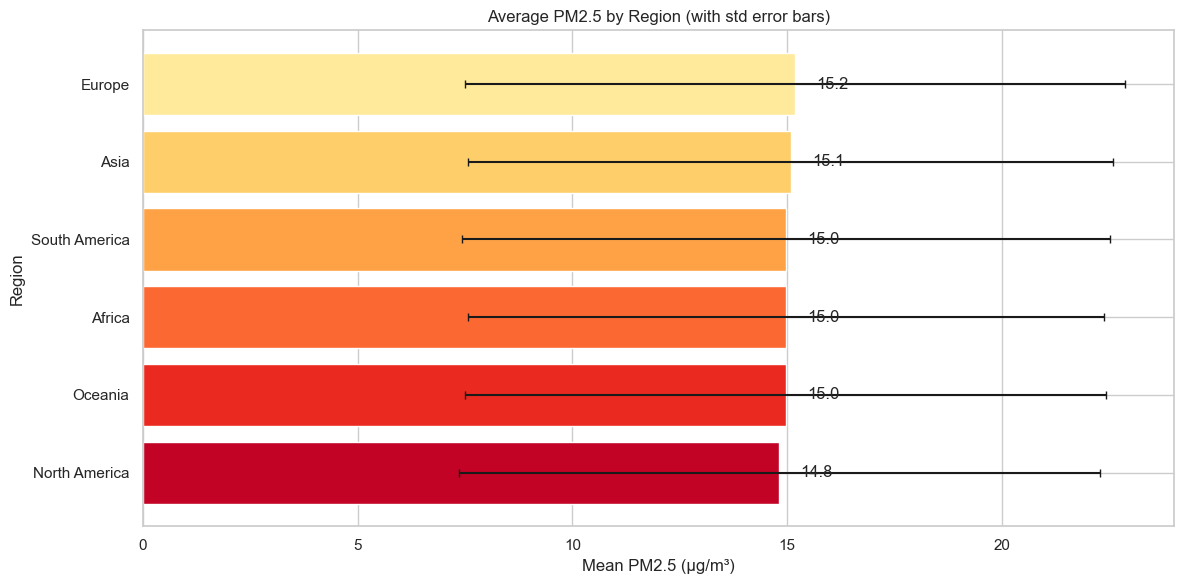

Saved: C:\Users\lucas\OneDrive\Desktop\pma-weather-forecasting\reports\env_airquality_by_region.png


In [8]:
# Target PM2.5 as primary air quality metric
pm25_col = "air_quality_PM2.5"

if pm25_col in df.columns:
    regional = df.groupby("region")[pm25_col].agg(["mean", "std", "count"]).reset_index()
    regional = regional[regional["count"] >= 100].sort_values("mean", ascending=False)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors = sns.color_palette("YlOrRd", n_colors=len(regional))
    bars = ax.barh(regional["region"], regional["mean"], xerr=regional["std"]/2, color=colors, capsize=3)
    
    ax.set_xlabel("Mean PM2.5 (\u03bcg/m\u00b3)")
    ax.set_ylabel("Region")
    ax.set_title("Average PM2.5 by Region (with std error bars)")
    ax.invert_yaxis()
    
    for bar, val in zip(bars, regional["mean"]):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f"{val:.1f}", va="center")
    
    plt.tight_layout()
    out_path = reports_dir / "env_airquality_by_region.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)
else:
    print(f"Column {pm25_col} not found")

## 7. Feature Importance: Random Forest

Train RandomForest to predict PM2.5 and extract feature importances.

In [9]:
# Prepare data for ML
target = pm25_col
features = weather_cols

ml_df = df[features + [target]].dropna()
print(f"ML dataset size: {len(ml_df):,}")

X = ml_df[features]
y = ml_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train):,}, Test: {len(X_test):,}")

ML dataset size: 133,000
Train: 106,400, Test: 26,600


In [10]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)

rf_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_,
}).sort_values("Importance", ascending=False)

print("Random Forest Feature Importance (for PM2.5):")
display(rf_importance)

Random Forest Feature Importance (for PM2.5):


,Feature,Importance
5,precip_mm,0.121944
8,visibility_km,0.113729
4,pressure_mb,0.109616
1,humidity,0.106698
7,feelslike_celsius,0.103896
10,gust_kph,0.097545
0,temperature_celsius,0.090727
2,wind_kph,0.089263
3,wind_degree,0.077028
6,cloud,0.062882


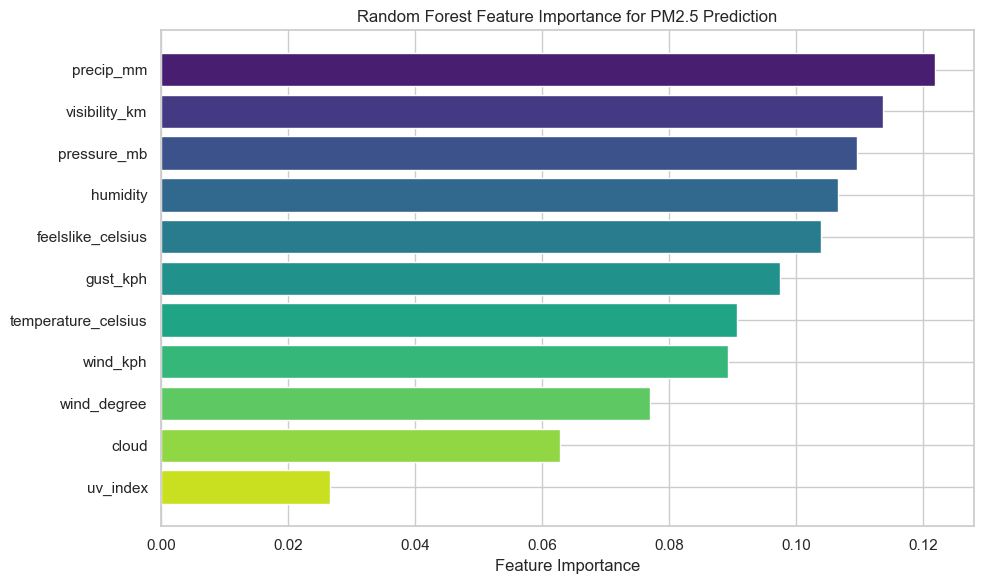

Saved: C:\Users\lucas\OneDrive\Desktop\pma-weather-forecasting\reports\env_rf_feature_importance.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = sns.color_palette("viridis", n_colors=len(rf_importance))
ax.barh(rf_importance["Feature"], rf_importance["Importance"], color=colors)
ax.set_xlabel("Feature Importance")
ax.set_title("Random Forest Feature Importance for PM2.5 Prediction")
ax.invert_yaxis()

plt.tight_layout()
out_path = reports_dir / "env_rf_feature_importance.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

## 8. Feature Importance: LightGBM

Train LightGBM and compare feature importances.

In [12]:
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val = lgb.Dataset(X_test, label=y_test, reference=lgb_train)

lgb_params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "num_leaves": 31,
    "learning_rate": 0.05,
    "feature_fraction": 0.8,
    "verbose": -1,
    "seed": 42,
}

lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=200,
    valid_sets=[lgb_train, lgb_val],
    valid_names=["train", "valid"],
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)],
)

lgb_importance = pd.DataFrame({
    "Feature": features,
    "Importance": lgb_model.feature_importance(importance_type="gain"),
}).sort_values("Importance", ascending=False)

print("LightGBM Feature Importance (gain):")
display(lgb_importance)

LightGBM Feature Importance (gain):


,Feature,Importance
3,wind_degree,13501.460205
1,humidity,10528.420044
8,visibility_km,10047.559937
4,pressure_mb,7428.380005
6,cloud,5967.209961
0,temperature_celsius,5843.810059
5,precip_mm,4724.770020
7,feelslike_celsius,3255.430054
2,wind_kph,0.000000
9,uv_index,0.000000


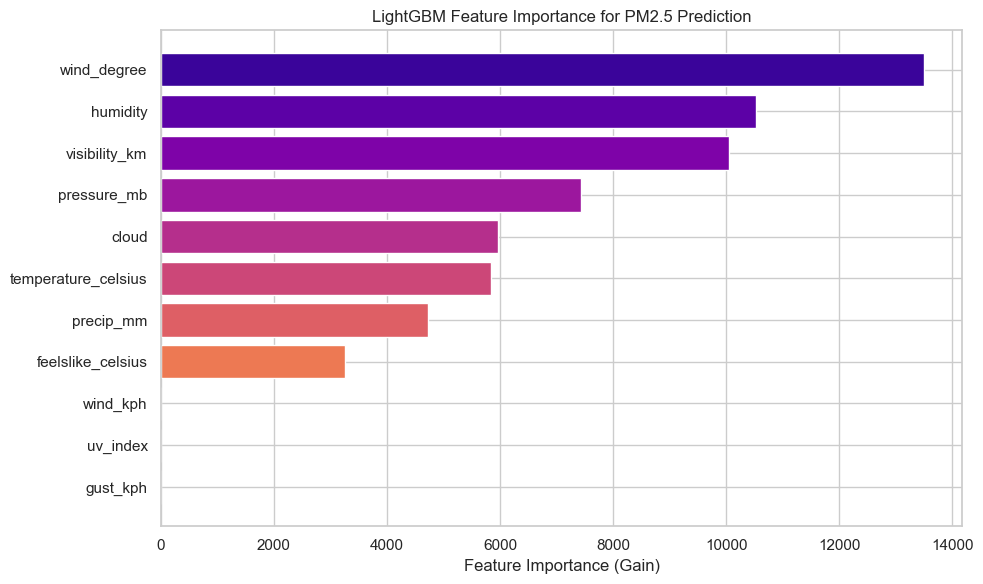

Saved: C:\Users\lucas\OneDrive\Desktop\pma-weather-forecasting\reports\env_lgb_feature_importance.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = sns.color_palette("plasma", n_colors=len(lgb_importance))
ax.barh(lgb_importance["Feature"], lgb_importance["Importance"], color=colors)
ax.set_xlabel("Feature Importance (Gain)")
ax.set_title("LightGBM Feature Importance for PM2.5 Prediction")
ax.invert_yaxis()

plt.tight_layout()
out_path = reports_dir / "env_lgb_feature_importance.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

## 9. SHAP Analysis

Use SHAP values for model-agnostic feature importance and interpretability.

In [14]:
# Use a sample for SHAP analysis (faster computation)
X_sample = X_test.sample(min(1000, len(X_test)), random_state=42)

# Create SHAP explainer for LightGBM
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_sample)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (1000, 11)


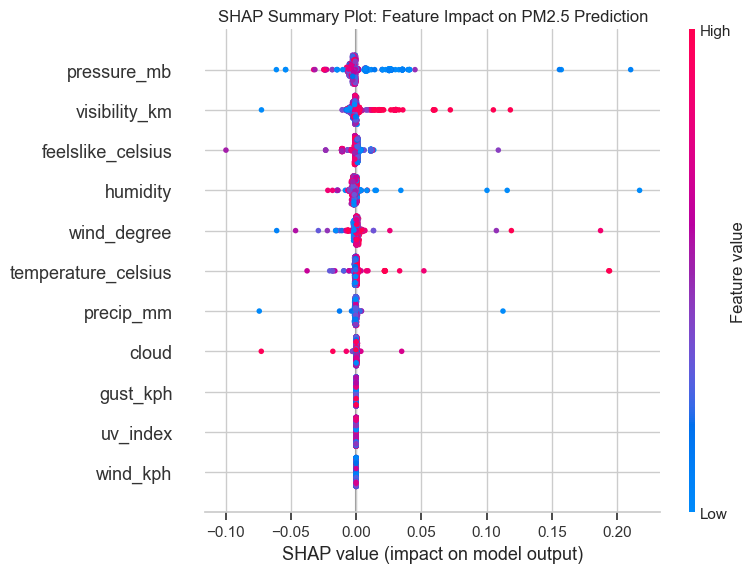

Saved: C:\Users\lucas\OneDrive\Desktop\pma-weather-forecasting\reports\env_shap_summary.png


In [15]:
# SHAP Summary Plot
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Summary Plot: Feature Impact on PM2.5 Prediction")
plt.tight_layout()
out_path = reports_dir / "env_shap_summary.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

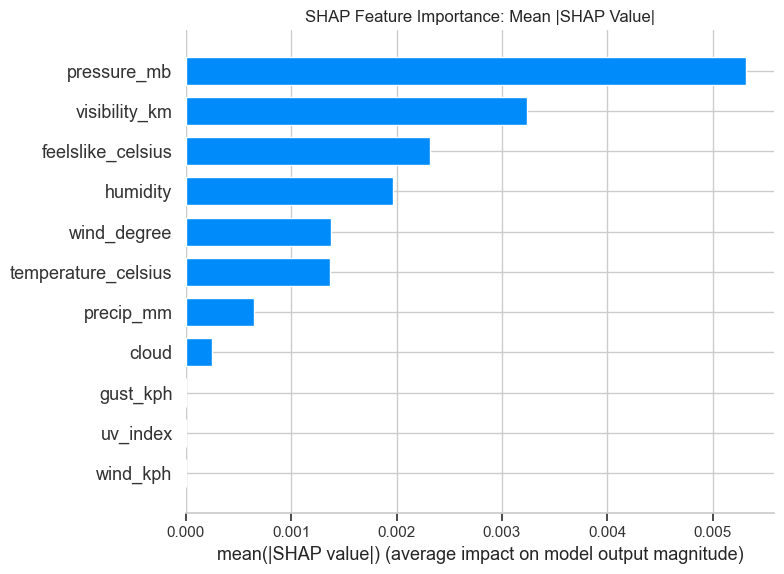

Saved: C:\Users\lucas\OneDrive\Desktop\pma-weather-forecasting\reports\env_shap_bar.png


In [16]:
# SHAP Bar Plot (mean absolute SHAP values)
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance: Mean |SHAP Value|")
plt.tight_layout()
out_path = reports_dir / "env_shap_bar.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

## 10. Feature Importance Comparison

Compare rankings from Random Forest, LightGBM, and SHAP.

In [17]:
# Calculate mean absolute SHAP values
shap_importance = pd.DataFrame({
    "Feature": features,
    "SHAP": np.abs(shap_values).mean(axis=0),
})

# Merge all importances
comparison = rf_importance.rename(columns={"Importance": "RandomForest"})
comparison = comparison.merge(
    lgb_importance.rename(columns={"Importance": "LightGBM"}),
    on="Feature"
)
comparison = comparison.merge(shap_importance, on="Feature")

# Normalize for comparison (0-1 scale)
for col in ["RandomForest", "LightGBM", "SHAP"]:
    comparison[f"{col}_norm"] = (comparison[col] - comparison[col].min()) / (comparison[col].max() - comparison[col].min())

# Add rank columns
for col in ["RandomForest", "LightGBM", "SHAP"]:
    comparison[f"{col}_rank"] = comparison[col].rank(ascending=False).astype(int)

print("Feature Importance Comparison:")
display(comparison[["Feature", "RandomForest_rank", "LightGBM_rank", "SHAP_rank"]])

Feature Importance Comparison:


,Feature,RandomForest_rank,LightGBM_rank,SHAP_rank
0,precip_mm,1,7,7
1,visibility_km,2,3,2
2,pressure_mb,3,4,1
3,humidity,4,2,4
4,feelslike_celsius,5,8,3
5,gust_kph,6,10,10
6,temperature_celsius,7,6,6
7,wind_kph,8,10,10
8,wind_degree,9,1,5
9,cloud,10,5,8


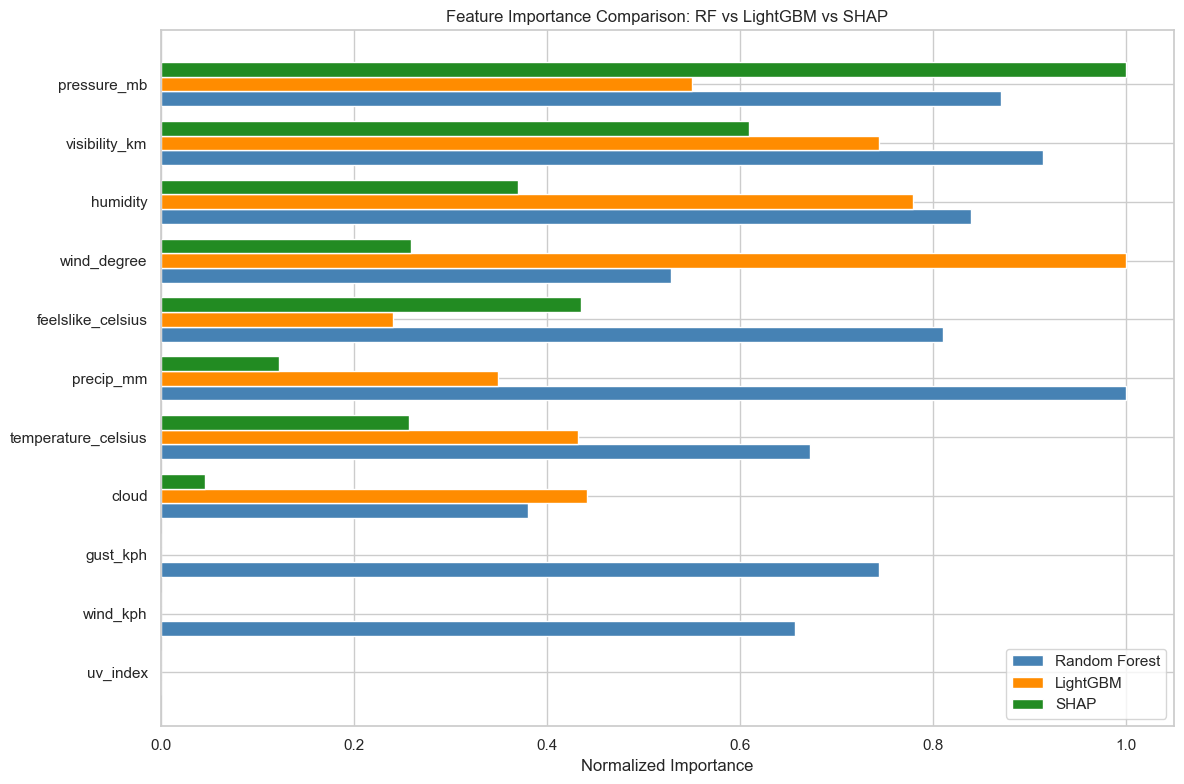

Saved: C:\Users\lucas\OneDrive\Desktop\pma-weather-forecasting\reports\env_feature_importance_comparison.png


In [18]:
# Visualization: Comparison
fig, ax = plt.subplots(figsize=(12, 8))

x = np.arange(len(comparison))
width = 0.25

# Sort by average normalized importance
comparison["avg_norm"] = (comparison["RandomForest_norm"] + comparison["LightGBM_norm"] + comparison["SHAP_norm"]) / 3
comparison = comparison.sort_values("avg_norm", ascending=True)

ax.barh(x - width, comparison["RandomForest_norm"], width, label="Random Forest", color="steelblue")
ax.barh(x, comparison["LightGBM_norm"], width, label="LightGBM", color="darkorange")
ax.barh(x + width, comparison["SHAP_norm"], width, label="SHAP", color="forestgreen")

ax.set_yticks(x)
ax.set_yticklabels(comparison["Feature"])
ax.set_xlabel("Normalized Importance")
ax.set_title("Feature Importance Comparison: RF vs LightGBM vs SHAP")
ax.legend(loc="lower right")

plt.tight_layout()
out_path = reports_dir / "env_feature_importance_comparison.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

## 11. Summary

**Key Findings:**

1. **Weather-Air Quality Correlations:**
   - Identified significant correlations between weather variables and air quality metrics
   - Top correlating pairs reveal environmental relationships

2. **Regional Analysis:**
   - PM2.5 levels vary significantly across regions
   - Geographic and climate factors influence air quality

3. **Feature Importance (for PM2.5 prediction):**
   - Random Forest, LightGBM, and SHAP provide complementary views
   - Consistent top features across methods indicate robust findings
   - SHAP values provide direction of influence (positive/negative)

**Outputs:**
- `reports/env_air_quality_distributions.png`
- `reports/env_weather_airquality_correlation.png`
- `reports/env_top_correlations_scatter.png`
- `reports/env_airquality_by_region.png`
- `reports/env_rf_feature_importance.png`
- `reports/env_lgb_feature_importance.png`
- `reports/env_shap_summary.png`
- `reports/env_shap_bar.png`
- `reports/env_feature_importance_comparison.png`